In [59]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler



In [60]:
df = pd.read_csv('income.csv')

In [61]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


Text(0, 0.5, 'Income')

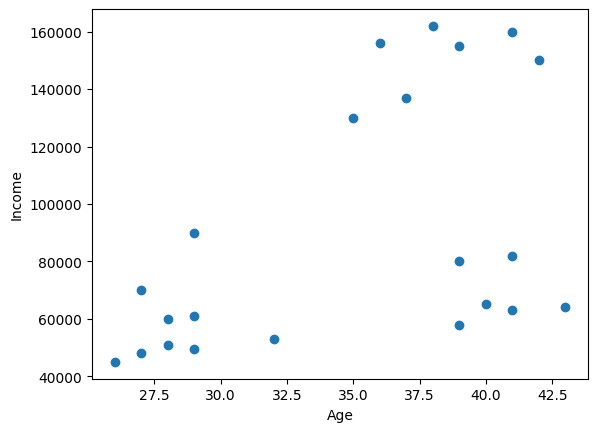

In [62]:
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income')

In [63]:
km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(df[['Age','Income($)']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [64]:
df['cluster']  = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [65]:
km.cluster_centers_

array([[3.32000000e+01, 6.26333333e+04],
       [3.92000000e+01, 1.56600000e+05],
       [3.60000000e+01, 1.33500000e+05]])

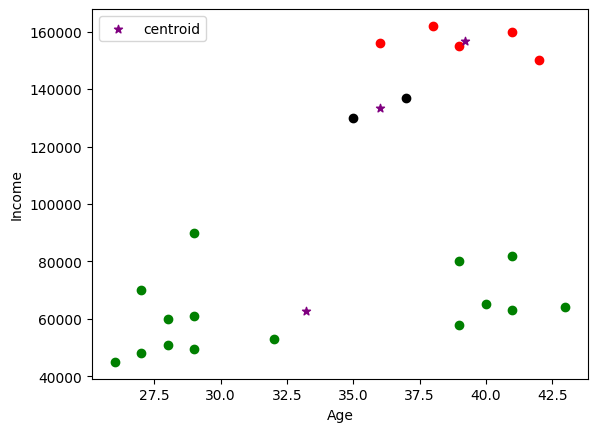

In [66]:
df1 = df[df['cluster'] == 0]
df2 = df[df['cluster'] == 1]
df3 = df[df['cluster'] == 2]
plt.scatter(df1.Age, df1['Income($)'], color = 'green')
plt.scatter(df2.Age, df2['Income($)'], color = 'red')
plt.scatter(df3.Age, df3['Income($)'], color = 'black')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1] , color = 'purple', marker='*', label='centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()


In [67]:
scaler = MinMaxScaler()
 
scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])
 
 

In [68]:

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
 
 

In [69]:
km_1 = KMeans(n_clusters=3)
y_predicted_1 = km_1.fit_predict(df[['Age','Income($)']])

In [70]:
df['cluster'] = y_predicted_1
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,1
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


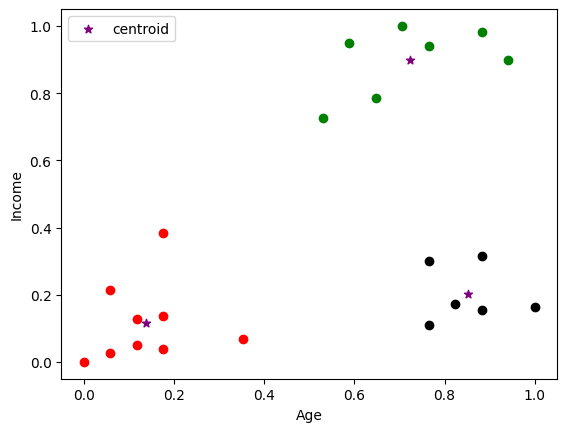

In [71]:
df1 = df[df['cluster'] == 0]
df2 = df[df['cluster'] == 1]
df3 = df[df['cluster'] == 2]
plt.scatter(df1.Age, df1['Income($)'], color='green')
plt.scatter(df2.Age, df2['Income($)'], color='red')
plt.scatter(df3.Age, df3['Income($)'], color='black')

plt.scatter(km_1.cluster_centers_[:, 0],
			km_1.cluster_centers_[:, 1],
			color='purple', marker='*', label='centroid')
plt.xlabel('Age')
plt.ylabel('Income')
plt.legend()

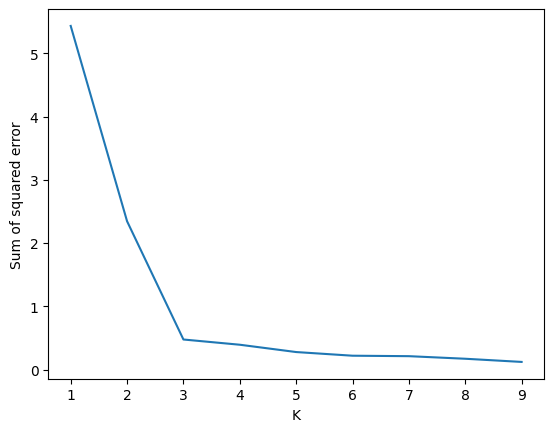

In [74]:
sse =[]
k_rng = range(1,10)
for k in k_rng:
    km = KMeans (n_clusters=k)
    km.fit(df[['Age', 'Income($)']])
    sse.append(km.inertia_)
plt.xlabel('K')
plt.ylabel('Sum of squared error')
plt.plot(k_rng, sse)